<a href="https://colab.research.google.com/github/swethaukkarde/Neural-networks-and-deep-learning/blob/main/Exp_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.1/100.1 MB 6.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for face-recognition-models: filename=face_recognition_models-0.3.0-py2.py3-none-any.whl size=100566166 sha256=a5cb479b8de9fc75e97ef68e687debd822f5548d0c5db444016824a8e547deaf
  Stored in directory: /root/.cache/pip/wheels/8f/47/c8/f44c5aebb7507f7c8a2c0bd23151d732d0f0bd6884ad4ac635
Successfully built face-recognition-models
Upload known student image


Saving ProfilePic.png to ProfilePic.png
Upload test image


Saving 3.jpg to 3.jpg
Student1 marked present at 2026-04-10 06:02:32.076791


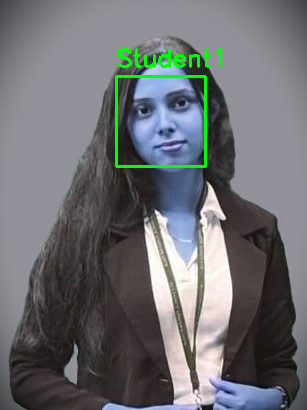

In [1]:
# Install required libraries
!pip install face_recognition
!apt-get -qq install -y libgl1

import cv2
import face_recognition
import numpy as np
from google.colab import files
from datetime import datetime

# -------------------------------
# Step 1: Upload known image
# -------------------------------
print("Upload known student image")
known_upload = files.upload()

known_name = list(known_upload.keys())[0]
known_image = face_recognition.load_image_file(known_name)
known_encoding = face_recognition.face_encodings(known_image)[0]

# -------------------------------
# Step 2: Upload test image
# -------------------------------
print("Upload test image")
test_upload = files.upload()

test_name = list(test_upload.keys())[0]
test_image = face_recognition.load_image_file(test_name)

# -------------------------------
# Step 3: Face Detection
# -------------------------------
face_locations = face_recognition.face_locations(test_image)
face_encodings = face_recognition.face_encodings(test_image, face_locations)

attendance = []

# -------------------------------
# Step 4: Compare Faces
# -------------------------------
for face_encoding, face_location in zip(face_encodings, face_locations):
    match = face_recognition.compare_faces([known_encoding], face_encoding)[0]

    name = "Unknown"
    if match:
        name = "Student1"
        attendance.append(name)
        print(f"{name} marked present at {datetime.now()}")

    # Draw box
    top, right, bottom, left = face_location
    cv2.rectangle(test_image, (left, top), (right, bottom), (0,255,0), 2)
    cv2.putText(test_image, name, (left, top-10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0,255,0), 2)

# -------------------------------
# Step 5: Show Output
# -------------------------------
from google.colab.patches import cv2_imshow
cv2_imshow(test_image)